# Chicago Taxi Trips Analysis 🚕

## Overview
Analysis of Chicago taxi trips (2023) using BigQuery public dataset.

**Key Questions:**
- Which companies dominate the market?
- What are the peak hours for taxi rides?
- How does payment type affect tips?

**Stack:** BigQuery · Python · Pandas · Matplotlib

In [21]:
import warnings
warnings.filterwarnings('ignore')

from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt

client = bigquery.Client(project='project-b7e71fb0-039e-408e-a0e')
print("Connected to BigQuery!")

Connected to BigQuery!


## 1. Market Share by Company
Which taxi companies dominate Chicago in 2023?

In [22]:
query_market = """
SELECT 
    company,
    COUNT(*) AS trips,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) AS market_share_pct
FROM `bigquery-public-data.chicago_taxi_trips.taxi_trips`
WHERE EXTRACT(YEAR FROM trip_start_timestamp) = 2023
GROUP BY company
ORDER BY trips DESC
LIMIT 10
"""

df_market = client.query(query_market).to_dataframe()
df_market

,company,trips,market_share_pct
0,Flash Cab,1259259,19.39
1,Taxi Affiliation Services,1240985,19.11
2,Sun Taxi,721689,11.11
3,City Service,652206,10.04
4,Taxicab Insurance Agency Llc,618953,9.53
5,Chicago Independents,379528,5.84
6,5 Star Taxi,299448,4.61
7,Globe Taxi,236961,3.65
8,Medallion Leasin,225373,3.47
9,Blue Ribbon Taxi Association,205906,3.17


## 2. Peak Hours Analysis
When do people take taxis most often?

In [23]:
query_hours = """
SELECT 
    EXTRACT(HOUR FROM trip_start_timestamp) AS hour,
    COUNT(*) AS trips
FROM `bigquery-public-data.chicago_taxi_trips.taxi_trips`
WHERE EXTRACT(YEAR FROM trip_start_timestamp) = 2023
GROUP BY hour
ORDER BY trips DESC
"""

df_hours = client.query(query_hours).to_dataframe()
df_hours

,hour,trips
0,17,464145
1,16,449681
2,15,439808
3,18,438402
4,14,426965
5,13,420486
6,12,410187
7,19,394308
8,11,380996
9,10,360807


## 3. Payment Type Analysis
How does payment method affect tips?

In [24]:
query_payment = """
SELECT 
    payment_type,
    COUNT(*) AS trips,
    ROUND(AVG(fare), 2) AS avg_fare,
    ROUND(AVG(tips), 2) AS avg_tips,
    ROUND(AVG(tips) / NULLIF(AVG(fare), 0) * 100, 2) AS tip_pct
FROM `bigquery-public-data.chicago_taxi_trips.taxi_trips`
WHERE EXTRACT(YEAR FROM trip_start_timestamp) = 2023
  AND fare > 0
GROUP BY payment_type
ORDER BY trips DESC
"""

df_payment = client.query(query_payment).to_dataframe()
df_payment

,payment_type,trips,avg_fare,avg_tips,tip_pct
0,Credit Card,2646385,27.16,6.05,22.26
1,Cash,1931131,17.35,0.02,0.12
2,Mobile,958159,16.17,3.25,20.12
3,Prcard,647174,25.41,0.22,0.85
4,Unknown,290679,23.50,0.00,0.02
5,No Charge,2513,33.23,0.27,0.82
6,Dispute,1861,26.89,0.02,0.06


## Visualizations

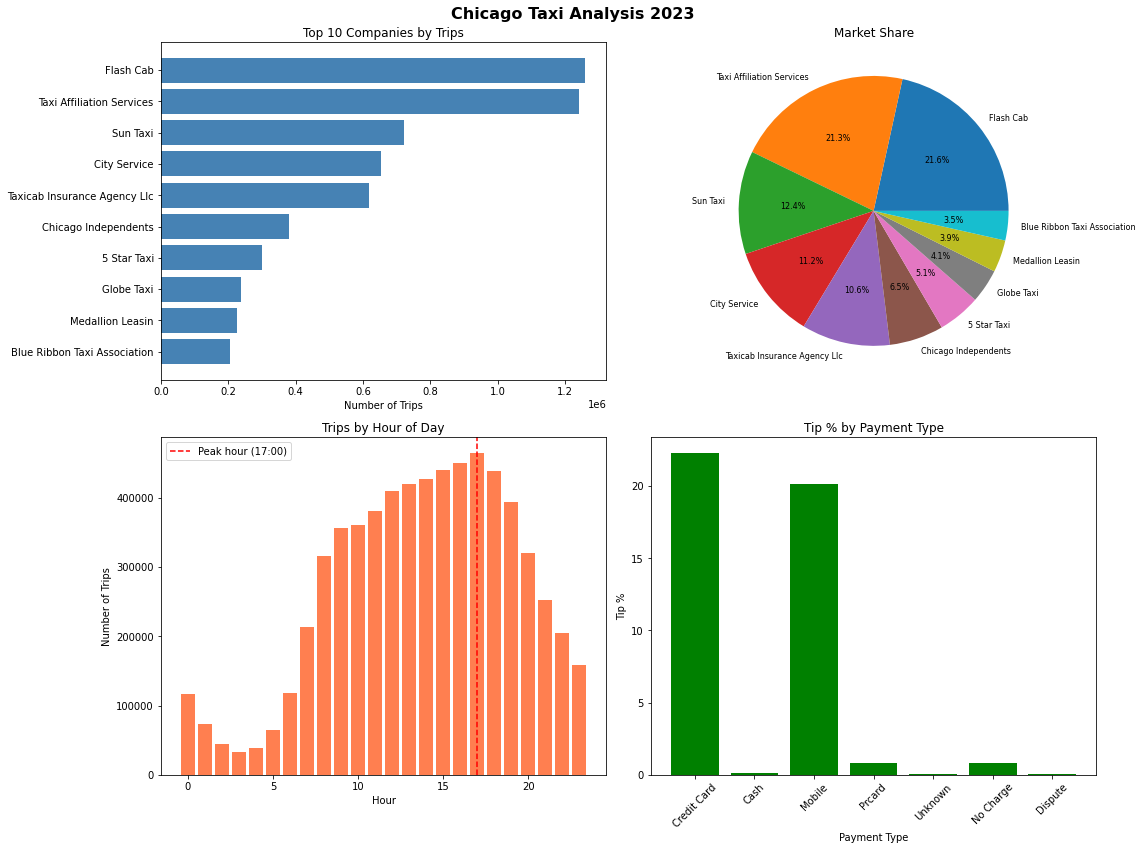

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Chicago Taxi Analysis 2023', fontsize=16, fontweight='bold')

# График 1 — доля рынка
axes[0,0].barh(df_market['company'], df_market['trips'], color='steelblue')
axes[0,0].set_title('Top 10 Companies by Trips')
axes[0,0].set_xlabel('Number of Trips')
axes[0,0].invert_yaxis()

# График 2 — круговая диаграмма
axes[0,1].pie(df_market['market_share_pct'], 
              labels=df_market['company'], 
              autopct='%1.1f%%',
              textprops={'fontsize': 8})
axes[0,1].set_title('Market Share')

# График 3 — часы пик
axes[1,0].bar(df_hours['hour'], df_hours['trips'], color='coral')
axes[1,0].set_title('Trips by Hour of Day')
axes[1,0].set_xlabel('Hour')
axes[1,0].set_ylabel('Number of Trips')
axes[1,0].axvline(x=17, color='red', linestyle='--', label='Peak hour (17:00)')
axes[1,0].legend()

# График 4 — чаевые по способу оплаты
axes[1,1].bar(df_payment['payment_type'], df_payment['tip_pct'], color='green')
axes[1,1].set_title('Tip % by Payment Type')
axes[1,1].set_xlabel('Payment Type')
axes[1,1].set_ylabel('Tip %')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('chicago_taxi_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## Key Findings

1. **Market concentration** — Flash Cab and Taxi Affiliation Services control 38.5% of the market
2. **Peak hours** — Evening rush hour (15:00-18:00) has the most rides
3. **Payment and tips** — Credit card users tip 22% vs only 0.12% for cash payments
4. **Night market** — Rides drop sharply after midnight, Chicago is not a 24/7 city